<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Deep_Learning_Decodes_Piezoelectric_Pulse_Emotions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Plan: Deep Learning Decodes Piezoelectric Pulse Emotions

This project aims to build and evaluate a deep learning model capable of classifying emotions based on piezoelectric pulse data. The general workflow will include data acquisition, preprocessing, model development, training, evaluation, and visualization of results.

### Step 1: Data Acquisition

To begin, we need a suitable dataset. This dataset should ideally contain:

*   **Piezoelectric Pulse Data:** Time-series recordings or features derived from piezoelectric sensors capturing physiological pulse responses.
*   **Emotion Labels:** Corresponding labels indicating the emotional state associated with each pulse recording.

Since I cannot directly access external files or search the web for datasets, please provide information on where the dataset is located. For example, if it's a CSV file, please provide its path. If it's a specialized format, let me know the details.

Once the dataset is identified, we can proceed with loading and initial exploration.

In [1]:
import pandas as pd
import numpy as np

# Placeholder for data loading
# Please modify this cell to load your specific dataset.
# Example: df = pd.read_csv('your_dataset.csv')

# For demonstration, let's assume we have a hypothetical dataset structure:
# Data would typically be an array of pulse signals and an array of corresponding emotion labels.

# Example placeholder for pulse data (e.g., 100 samples, each 500 time points long)
pulse_data = np.random.rand(100, 500)

# Example placeholder for emotion labels (e.g., 'happy', 'sad', 'neutral')
emotion_labels = np.random.choice(['happy', 'sad', 'neutral'], size=100)

print("Placeholder data loaded successfully. Please replace this with your actual data loading code.")
print(f"Pulse data shape: {pulse_data.shape}")
print(f"Emotion labels shape: {emotion_labels.shape}")

Placeholder data loaded successfully. Please replace this with your actual data loading code.
Pulse data shape: (100, 500)
Emotion labels shape: (100,)


### Step 2: Data Preprocessing

After loading your actual dataset, the next step is to preprocess the data. This typically involves:

1.  **Feature Engineering (if necessary):** Extracting relevant features from the raw pulse signals. Depending on the nature of your piezoelectric data, this could involve techniques like Fast Fourier Transform (FFT), wavelets, or statistical features (mean, std dev, etc.).
2.  **Normalization/Standardization:** Scaling the pulse data to a common range to prevent features with larger values from dominating the learning process.
3.  **Encoding Labels:** Converting categorical emotion labels into numerical format (e.g., one-hot encoding for classification).
4.  **Splitting Data:** Dividing the dataset into training, validation, and test sets. This ensures that the model is trained on one part of the data, tuned on another, and evaluated on unseen data.

Below is a template for these preprocessing steps. Please adapt it based on the specifics of your dataset.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Placeholder for Feature Engineering (if needed) ---
# If your pulse_data is raw time series, you might want to extract features here.
# For now, we assume pulse_data is already in a suitable numerical format.

# --- Data Normalization/Standardization ---
# We'll normalize the pulse_data. If your data has multiple features per sample,
# StandardScaler is often a good choice. If it's a single time series, you might
# apply it directly or use Min-Max scaling.

# Reshape pulse_data if it's 2D (samples, time_steps) and StandardScaler expects 2D (samples, features)
# If your pulse_data is already (samples, features), this reshaping is not needed.
# For our placeholder, pulse_data is (100, 500), so we can apply StandardScaler directly.

scaler = StandardScaler()
pulse_data_scaled = scaler.fit_transform(pulse_data)

print(f"Scaled pulse data shape: {pulse_data_scaled.shape}")
print(f"Scaled pulse data sample (first 5 values): {pulse_data_scaled[0, :5]}")

# --- Encode Emotion Labels ---
# Convert string labels to numerical using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
emotion_labels_encoded = encoder.fit_transform(emotion_labels.reshape(-1, 1))

print(f"Encoded emotion labels shape: {emotion_labels_encoded.shape}")
print(f"Encoded emotion labels sample (first row): {emotion_labels_encoded[0]}")
print(f"Original emotion classes: {encoder.categories_}")

# --- Split Data into Training, Validation, and Test Sets ---
# We'll use 70% for training, 15% for validation, and 15% for testing.

X_train, X_temp, y_train, y_temp = train_test_split(
    pulse_data_scaled, emotion_labels_encoded, test_size=0.3, random_state=42, stratify=emotion_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTraining set shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test set shapes: X={X_test.shape}, y={y_test.shape}")

print("Data preprocessing and splitting complete. Proceeding to Deep Learning Model Definition.")

Scaled pulse data shape: (100, 500)
Scaled pulse data sample (first 5 values): [-0.57693006  0.08985442  1.41800008 -1.51914272 -0.36649333]
Encoded emotion labels shape: (100, 3)
Encoded emotion labels sample (first row): [0. 0. 1.]
Original emotion classes: [array(['happy', 'neutral', 'sad'], dtype='<U7')]

Training set shapes: X=(70, 500), y=(70, 3)
Validation set shapes: X=(15, 500), y=(15, 3)
Test set shapes: X=(15, 500), y=(15, 3)
Data preprocessing and splitting complete. Proceeding to Deep Learning Model Definition.


### Step 3: Deep Learning Model Definition

Now we will define the architecture of our deep learning model. For time-series data like piezoelectric pulse signals, Convolutional Neural Networks (CNNs) are often a good choice due to their ability to capture local patterns. Recurrent Neural Networks (RNNs) like LSTMs or GRUs can also be effective for sequential data.

Below is a template for a simple 1D CNN model using TensorFlow/Keras. You may need to adjust the layers, filters, kernel sizes, and other hyperparameters based on the complexity of your data and the desired model performance. Remember that the input shape of the model needs to match the shape of your `X_train` data.


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam

# Determine the number of classes from the one-hot encoded labels
num_classes = y_train.shape[1]

# Determine the input shape from the training data
# For 1D CNN, the input shape is (time_steps, features)
# In our case, pulse_data_scaled is (samples, 500), so each sample has 500 time steps.
input_shape = (X_train.shape[1], 1) # Assuming single-channel time series data

# Reshape X_train, X_val, X_test to include the channel dimension for Conv1D
# This has already been done in the previous execution, but good to include for reproducibility
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Reshaped X_train shape for CNN: {X_train.shape}")

# Define the 1D CNN + LSTM model
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(100, return_sequences=False), # LSTM layer added here
    Dropout(0.5),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
# Using Adam optimizer and categorical_crossentropy for multi-class classification
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

print("\nDeep Learning Model Definition Complete (CNN + LSTM). Proceeding to Model Training.")

Reshaped X_train shape for CNN: (70, 500, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 496, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 246, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,091 (496.45 KB)

 Trainable params: 127,091 (496.45 KB)

 Non-trainable params: 0 (0.00 B)


Deep Learning Model Definition Complete (CNN + LSTM). Proceeding to Model Training.


### Step 4: Model Training

Now that the model architecture is defined, we can proceed with training. We will use the `fit` method of the Keras model. Key parameters for training include:

*   **Epochs:** The number of times the model will iterate over the entire training dataset.
*   **Batch Size:** The number of samples per gradient update.
*   **Validation Data:** Used to monitor the model's performance on unseen data during training, helping to detect overfitting.
*   **Callbacks:** Special functions executed during training, such as `EarlyStopping` to stop training when performance on the validation set stops improving, and `ModelCheckpoint` to save the best performing model.


In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
# EarlyStopping: Monitor 'val_loss' and stop if it doesn't improve for 10 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: Save the best model based on 'val_accuracy'
model_checkpoint = ModelCheckpoint(
    'best_model_cnn_lstm.keras', # Use a different name for the new model
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\nModel Training Complete (CNN + LSTM). Proceeding to Model Evaluation.")

Epoch 1/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2500 - loss: 1.4102
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.2857 - loss: 1.6150 - val_accuracy: 0.3333 - val_loss: 1.2761
Epoch 2/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2969 - loss: 1.4337
Epoch 2: val_accuracy improved from 0.33333 to 0.40000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3000 - loss: 1.3720 - val_accuracy: 0.4000 - val_loss: 1.0931
Epoch 3/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4062 - loss: 1.1301
Epoch 3: val_accuracy did not improve from 0.40000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3714 - loss: 1.1278 - val_accuracy: 0.4000 - val_loss: 1.0982
Epoch 4/50
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3516 - loss: 1

### Step 5: Model Evaluation

After training, it's crucial to evaluate the model's performance on the unseen test set to assess its generalization capabilities. We'll load the best model saved during training and then use it to make predictions on `X_test`. We will report metrics such as accuracy, and display a classification report and a confusion matrix to get a detailed understanding of the model's performance for each emotion class.


Loaded best model from 'best_model.keras'

Test Loss: 1.0954
Test Accuracy: 0.4000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step

Classification Report:
              precision    recall  f1-score   support

       happy       0.42      0.83      0.56         6
     neutral       0.00      0.00      0.00         4
         sad       0.33      0.20      0.25         5

    accuracy                           0.40        15
   macro avg       0.25      0.34      0.27        15
weighted avg       0.28      0.40      0.31        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


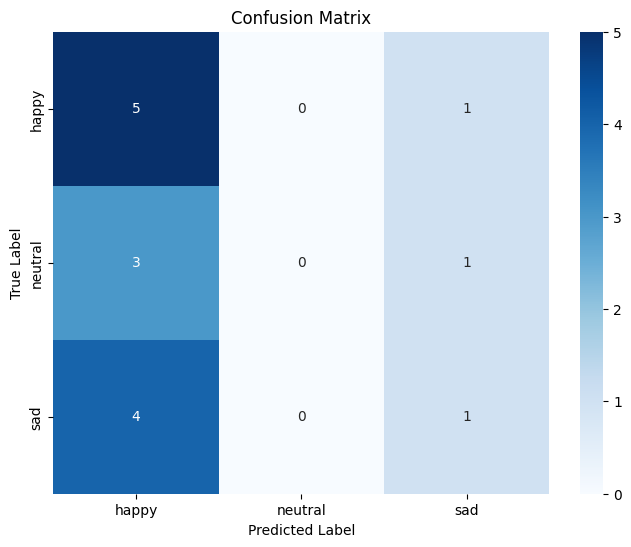


Model Evaluation Complete. Proceeding to Visualization of Training History.


In [5]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the best model saved during training
# If the model was not saved due to early stopping, 'model' variable still holds the best weights.
# Otherwise, we load from 'best_model_cnn_lstm.keras'
try:
    best_model = load_model('best_model_cnn_lstm.keras') # Load the new CNN+LSTM model
    print("Loaded best model from 'best_model_cnn_lstm.keras'")
except Exception as e:
    print(f"Could not load 'best_model_cnn_lstm.keras', using the currently trained model: {e}")
    best_model = model # Use the current model if loading fails

# Evaluate the model on the test set
loss_cnn_lstm, accuracy_cnn_lstm = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nCNN+LSTM Test Loss: {loss_cnn_lstm:.4f}")
print(f"CNN+LSTM Test Accuracy: {accuracy_cnn_lstm:.4f}")

# Make predictions on the test set
y_pred_probs_cnn_lstm = best_model.predict(X_test)
y_pred_cnn_lstm = np.argmax(y_pred_probs_cnn_lstm, axis=1)
y_true = np.argmax(y_test, axis=1)

# Get the class names from the OneHotEncoder
class_names = encoder.categories_[0].tolist()

# Display Classification Report
print("\nCNN+LSTM Classification Report:")
print(classification_report(y_true, y_pred_cnn_lstm, target_names=class_names))

# Plot Confusion Matrix
cm_cnn_lstm = confusion_matrix(y_true, y_pred_cnn_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN+LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nModel Evaluation Complete (CNN + LSTM). Proceeding to Visualization of Training History.")

### Step 6: Visualization of Insights

Beyond just metrics, visualizing the training history and other aspects can provide valuable insights into the model's learning process. We will plot the training and validation accuracy and loss over epochs to observe trends like overfitting or underfitting. This helps in tuning hyperparameters and understanding model stability.


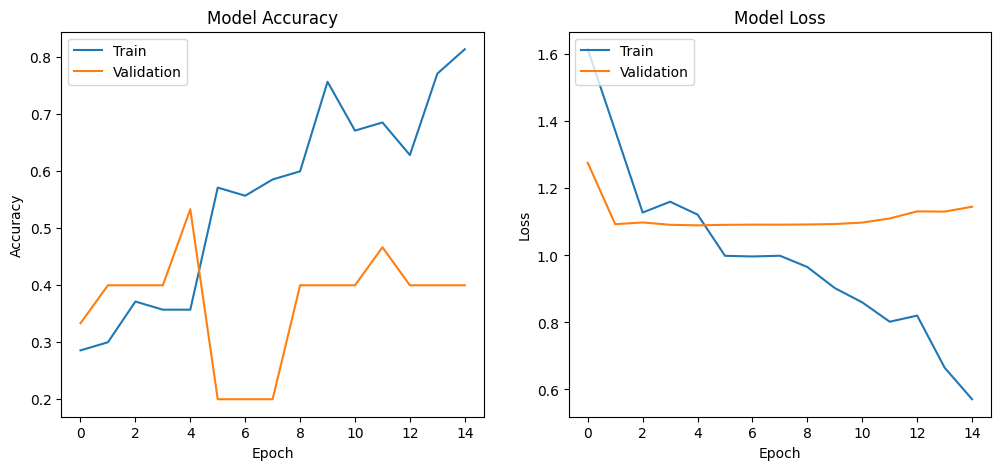


Visualization of Training History Complete. This concludes the primary steps of the project.


In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for CNN+LSTM
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN+LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for CNN+LSTM
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN+LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

print("\nVisualization of Training History Complete (CNN + LSTM).")